# 03 · Clasificación del resultado de un servicio

## Fase 1 CRISP-DM — Comprensión del negocio

La unidad de análisis es **una orden histórica**. El objetivo `outcome` tiene
tres clases: `completed_on_time`, `delayed` y `cancelled`. El modelo usa solo
datos disponibles al registrar el servicio para apoyar la planeación operativa;
no cambia el estado de la orden ni toma decisiones clínicas.

El error más costoso es pronosticar *a tiempo* cuando el servicio terminará
retrasado o cancelado, porque evita anticipar carga y avisar al paciente. Se usa
regresión logística multinomial: convierte puntajes lineales a probabilidades
con softmax y minimiza entropía cruzada ponderada con regularización L2. Es un
modelo apropiado para tres clases e interpretable, aunque requiere vigilar
calibración, deriva y el alto porcentaje de datos sintéticos.

Referencias: Hosmer, Lemeshow y Sturdivant (2013), *Applied Logistic
Regression*; Hastie, Tibshirani y Friedman (2009), *The Elements of Statistical
Learning*.

In [1]:
from pathlib import Path
import hashlib, json, math, os, subprocess, unicodedata
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

RED, BLACK, GRAY, WHITE = '#C8102E', '#111111', '#777777', '#FFFFFF'
plt.rcParams.update({'figure.facecolor': WHITE, 'axes.facecolor': WHITE,
                     'font.size': 10, 'axes.titleweight': 'bold'})

candidates = [Path.cwd(), *Path.cwd().parents]
BACKEND = next((p for p in candidates if (p / 'ml' / 'classification').exists()), None)
if BACKEND is None:
    PROJECT = next(p for p in candidates if (p / 'backend' / 'ml' / 'classification').exists())
    BACKEND = PROJECT / 'backend'
else:
    PROJECT = BACKEND.parent

# Ejecuta BD -> limpieza -> CSV -> train temporal -> evaluación -> artefacto.
npm = 'npm.cmd' if os.name == 'nt' else 'npm'
training = subprocess.run([npm, 'run', 'classification:train'], cwd=BACKEND,
                          check=True, capture_output=True, text=True)
print(training.stdout)

ML = BACKEND / 'ml' / 'classification'
EVIDENCE = PROJECT / '09_Evidencias'
EVIDENCE.mkdir(exist_ok=True)
CSV = ML / 'data' / 'classification_service_outcomes.csv'
TRAIN_CSV = ML / 'data' / 'classification_service_outcomes_train.csv'
TEST_CSV = ML / 'data' / 'classification_service_outcomes_test.csv'
ARTIFACT = ML / 'artifacts' / 'classification_service_outcome_model.json'
REPORT = ML / 'reports' / 'classification_training_report.json'

df = pd.read_csv(CSV, parse_dates=['source_created_at', 'source_updated_at'])
train_df = pd.read_csv(TRAIN_CSV, parse_dates=['source_created_at', 'source_updated_at'])
test_df = pd.read_csv(TEST_CSV, parse_dates=['source_created_at', 'source_updated_at'])
artifact = json.loads(ARTIFACT.read_text(encoding='utf-8'))
report = json.loads(REPORT.read_text(encoding='utf-8'))
csv_hash = hashlib.sha256(CSV.read_bytes()).hexdigest()
assert csv_hash == artifact['datasetSha256'] == report['datasetSha256']
assert set(train_df.order_id).isdisjoint(set(test_df.order_id))
assert train_df.source_created_at.max() <= test_df.source_created_at.min()

split = report['evaluationSplit']
print(f'Dataset verificado: {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'SHA-256: {csv_hash}')
print(f"Validación: {split['strategy']} por {split['orderingField']}")
print(f"Periodo elegible: {split['eligiblePeriod']['start']} a {split['eligiblePeriod']['end']}")


> backend@0.0.1 classification:train
> ts-node -r tsconfig-paths/register src/scripts/train-service-outcome-classification.ts

{
  "dataset": "05_Datasets/03_clasificacion_resultado_servicios.csv",
  "artifact": "07_Modelos/classification_service_outcome_model.json",
  "report": "07_Modelos/classification_training_report.json",
  "rows": 512,
  "syntheticRows": 500,
  "classDistribution": {
    "completed_on_time": 303,
    "delayed": 159,
    "cancelled": 50
  },
  "accuracy": 0.7647,
  "baselineAccuracy": 0.5588,
  "macroF1": 0.7146
}

Dataset verificado: 512 filas × 19 columnas
SHA-256: 41e6207feb0aeba5d2eb74674e2cf42de7d45a22c03fac8d2e62bdf4d2bce6ed
Validación: temporal_holdout por source_created_at
Periodo elegible: 2025-11-01T14:07:00.000Z a 2026-06-28T13:00:00.000Z


## Fase 2 CRISP-DM — Comprensión de los datos

El SQL versionado extrae una fila por orden. ID, folio, fechas y procedencia se
conservan para auditoría, pero nunca se entregan como X. Se revisan dimensiones,
tipos, nulos, cardinalidad, baja variabilidad y valores extremos con regla IQR.

In [2]:
display(pd.DataFrame({
    'concepto': ['Filas extraídas', 'Filas aceptadas', 'Filas rechazadas',
                 'Duplicados', 'Filas sintéticas', 'Filas reales'],
    'valor': [report['quality']['rowsExtracted'], report['quality']['rowsAccepted'],
              report['quality']['rowsRejected'], report['quality']['duplicateOrderIds'],
              report['quality']['syntheticRows'], report['quality']['realRows']]
}))
display(df.head(5))
quality = pd.DataFrame({'tipo': df.dtypes.astype(str),
                        'nulos': df.isna().sum(),
                        'porcentaje_nulos': (df.isna().mean() * 100).round(2)})
display(quality)
print('X usadas:', ', '.join(report['traceability']['predictorsX']))
print('Solo auditoría:', ', '.join(report['traceability']['auditOnlyNotUsedAsX']))

,concepto,valor
0,Filas extraídas,523
1,Filas aceptadas,512
2,Filas rechazadas,11
3,Duplicados,0
4,Filas sintéticas,500
5,Filas reales,12


,order_id,source_folio,is_synthetic,source_created_at,source_updated_at,promised_lead_hours,registration_hour,registration_weekday,item_count,total_quantity,distinct_study_count,package_component_count,subtotal_amount,courtesy_percent,discount_amount,total_amount,branch_name,dominant_price_type,outcome
0,663,ECO-ML-000137,1,2025-11-01 14:07:00+00:00,2025-11-01 16:07:00+00:00,20.0,8.116667,6,6,6,6,0,3683.5,5.0,184.18,3499.32,SUCURSAL SUR,special,cancelled
1,903,ECO-ML-000377,1,2025-11-01 14:07:00+00:00,2025-11-04 01:13:00+00:00,60.0,8.116667,6,6,6,6,0,3936.0,5.0,196.80,3739.20,SUCURSAL SUR,special,completed_on_time
2,560,ECO-ML-000034,1,2025-11-02 15:14:00+00:00,2025-11-05 13:47:00+00:00,57.0,9.233333,0,5,5,5,0,3369.5,10.0,336.95,3032.55,SUCURSAL SUR,dif,delayed
3,800,ECO-ML-000274,1,2025-11-02 15:14:00+00:00,2025-11-04 11:46:00+00:00,32.0,9.233333,0,5,5,5,0,2711.5,10.0,271.15,2440.35,SUCURSAL NORTE,dif,delayed
4,697,ECO-ML-000171,1,2025-11-03 16:21:00+00:00,2025-11-06 11:00:00+00:00,69.0,10.350000,1,4,4,4,0,2509.0,15.0,376.35,2132.65,SUCURSAL CENTRO,dif,completed_on_time


,tipo,nulos,porcentaje_nulos
order_id,int64,0,0.0
source_folio,str,0,0.0
is_synthetic,int64,0,0.0
source_created_at,"datetime64[us, UTC]",0,0.0
source_updated_at,"datetime64[us, UTC]",0,0.0
promised_lead_hours,float64,0,0.0
registration_hour,float64,0,0.0
registration_weekday,int64,0,0.0
item_count,int64,0,0.0
total_quantity,int64,0,0.0


X usadas: promisedLeadHours, registrationHour, registrationWeekday, itemCount, totalQuantity, distinctStudyCount, subtotalAmount, courtesyPercent, discountAmount, totalAmount, branchName, dominantPriceType
Solo auditoría: order_id, source_folio, source_created_at, source_updated_at, is_synthetic


In [3]:
numeric_eda = pd.DataFrame(report['exploratoryAnalysisX']['numeric']).T
categorical_eda = pd.DataFrame(report['exploratoryAnalysisX']['categorical']).T
display(numeric_eda[['nonNullCount', 'uniqueCount', 'dominantValueProportion',
                     'mean', 'standardDeviation', 'minimum', 'q1', 'median',
                     'q3', 'maximum', 'iqrOutlierCount', 'lowVariability']])
display(categorical_eda[['nullCount', 'cardinality',
                         'dominantValueProportion', 'lowVariability']])

,nonNullCount,uniqueCount,dominantValueProportion,mean,standardDeviation,minimum,q1,median,q3,maximum,iqrOutlierCount,lowVariability
promised_lead_hours,512,68,0.0313,39.426,18.8409,1,24,39,56,72,0,False
registration_hour,512,65,0.0176,12.8671,3.7304,0.5,9.8333,12.9833,15.9625,22.6,1,False
registration_weekday,512,7,0.1758,2.8984,2.0371,0,1,3,5,6,0,False
item_count,512,6,0.1797,3.4453,1.7199,1,2,3,5,6,0,False
total_quantity,512,6,0.1797,3.4453,1.7199,1,2,3,5,6,0,False
distinct_study_count,512,6,0.1797,3.4453,1.7199,1,2,3,5,6,0,False
package_component_count,512,3,0.9961,0.0098,0.159,0,0,0,0,3,2,True
subtotal_amount,512,468,0.0078,2036.4639,1090.6448,75,1042,1984.75,2949.5,4388,0,False
courtesy_percent,512,4,0.2676,7.3242,5.6396,0,0,5,10,15,0,False
discount_amount,512,358,0.2676,159.2032,162.1131,0,0,128.75,239.8125,658.2,4,False


,nullCount,cardinality,dominantValueProportion,lowVariability
branch_name,0,5,0.4219,False
dominant_price_type,0,5,0.5195,False


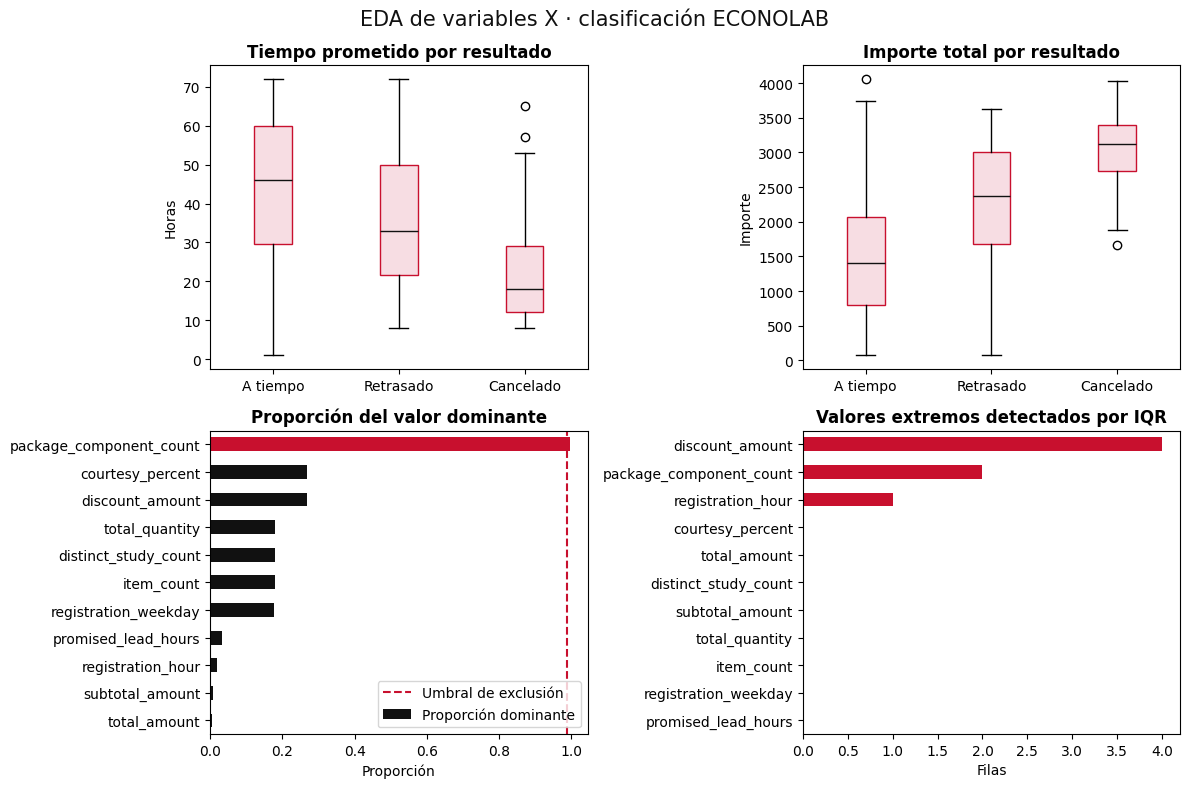

Evidencia: 09_Evidencias/clasificacion_eda_variables_x.png


In [4]:
classes = list(artifact['model']['classes'])
labels = {'completed_on_time': 'A tiempo', 'delayed': 'Retrasado',
          'cancelled': 'Cancelado'}
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].boxplot([df.loc[df.outcome.eq(c), 'promised_lead_hours'] for c in classes],
                   tick_labels=[labels[c] for c in classes], patch_artist=True,
                   boxprops={'facecolor': '#F7DDE3', 'color': RED},
                   medianprops={'color': BLACK})
axes[0, 0].set_title('Tiempo prometido por resultado')
axes[0, 0].set_ylabel('Horas')

axes[0, 1].boxplot([df.loc[df.outcome.eq(c), 'total_amount'] for c in classes],
                   tick_labels=[labels[c] for c in classes], patch_artist=True,
                   boxprops={'facecolor': '#F7DDE3', 'color': RED},
                   medianprops={'color': BLACK})
axes[0, 1].set_title('Importe total por resultado')
axes[0, 1].set_ylabel('Importe')

dominance = numeric_eda.dominantValueProportion.astype(float).sort_values()
dominance.plot.barh(ax=axes[1, 0],
                    color=[RED if v >= .99 else BLACK for v in dominance],
                    label='Proporción dominante')
axes[1, 0].axvline(.99, color=RED, linestyle='--', label='Umbral de exclusión')
axes[1, 0].set_title('Proporción del valor dominante')
axes[1, 0].set_xlabel('Proporción'); axes[1, 0].legend(loc='lower right')

outliers = numeric_eda.iqrOutlierCount.astype(int).sort_values()
outliers.plot.barh(ax=axes[1, 1], color=RED)
axes[1, 1].set_title('Valores extremos detectados por IQR')
axes[1, 1].set_xlabel('Filas')

fig.suptitle('EDA de variables X · clasificación ECONOLAB', fontsize=15, color=BLACK)
plt.tight_layout()
eda_path = EVIDENCE / 'clasificacion_eda_variables_x.png'
plt.savefig(eda_path, dpi=180, bbox_inches='tight', facecolor=WHITE)
plt.show()
print('Evidencia:', eda_path.relative_to(PROJECT).as_posix())

### Hallazgo y decisión del EDA

`package_component_count` tiene 99.61 % de ceros y solo dos observaciones no
cero: se conserva en el CSV para trazabilidad, pero el preprocesamiento ajustado
con train la excluye del artefacto por baja variabilidad. Las demás X candidatas
mantienen variación. Los extremos IQR válidos de hora de registro y descuento se
conservan porque pasan las reglas de negocio; se vigilarán como posible deriva.
Los conteos de ítems son muy correlacionados en los datos sintéticos, pero se
mantienen por su significado operativo distinto y la regularización L2 reduce
la inestabilidad; deberán reevaluarse con más historial real.

## Fase 3 CRISP-DM — Preparación de los datos

Se rechazan objetivos no disponibles, IDs duplicados, fechas inválidas,
intervalos no positivos e importes inconsistentes. El 20 % más reciente se
reserva como test **antes** de aprender imputación, medias, desviaciones,
categorías one-hot y pesos de clase. El artefacto desplegado es exactamente el
clasificador ajustado con train; no se reentrena con test.

,periodo,inicio,fin,filas
0,Elegible,2025-11-01T14:07:00.000Z,2026-06-28T13:00:00.000Z,512
1,Train (pasado),2025-11-01T14:07:00.000Z,2026-05-11T13:24:00.000Z,410
2,Test (futuro),2026-05-12T14:31:00.000Z,2026-06-28T13:00:00.000Z,102


,train,test
completed_on_time,246,57
delayed,123,36
cancelled,41,9


Traslape de IDs: 0
Train termina antes de iniciar test: True


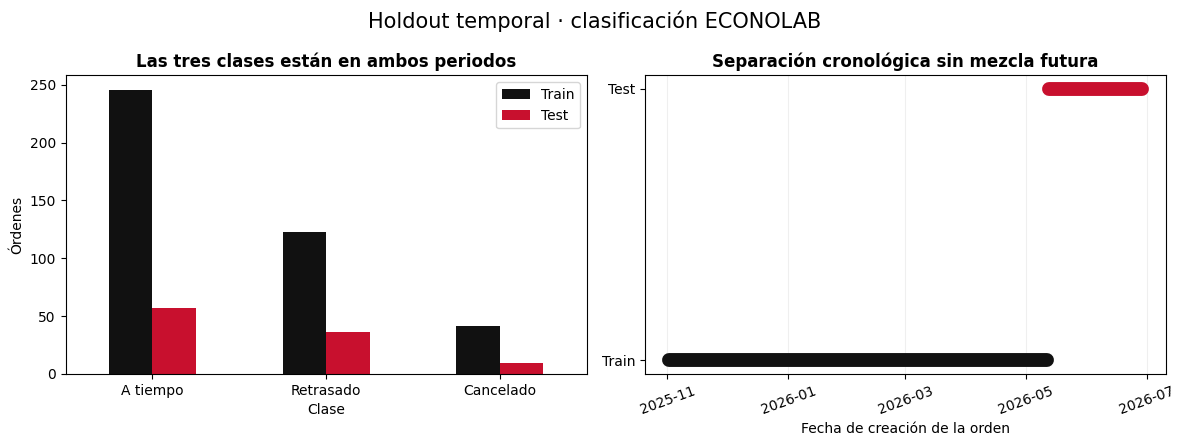

Evidencia: 09_Evidencias/clasificacion_balance_periodos.png


In [5]:
split_table = pd.DataFrame({
    'periodo': ['Elegible', 'Train (pasado)', 'Test (futuro)'],
    'inicio': [split['eligiblePeriod']['start'], split['trainingPeriod']['start'],
               split['testPeriod']['start']],
    'fin': [split['eligiblePeriod']['end'], split['trainingPeriod']['end'],
            split['testPeriod']['end']],
    'filas': [len(df), len(train_df), len(test_df)]
})
display(split_table)
display(pd.DataFrame({'train': split['trainingClassDistribution'],
                      'test': split['testClassDistribution']}))
print('Traslape de IDs:', split['overlapCount'])
print('Train termina antes de iniciar test:', split['trainEndsBeforeTestStarts'])

counts = pd.DataFrame({'Train': train_df.outcome.value_counts(),
                       'Test': test_df.outcome.value_counts()}).reindex(classes).fillna(0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
counts.rename(index=labels).plot.bar(ax=axes[0], color=[BLACK, RED])
axes[0].set_title('Las tres clases están en ambos periodos')
axes[0].set_xlabel('Clase'); axes[0].set_ylabel('Órdenes'); axes[0].tick_params(axis='x', rotation=0)

periods = [('Train', train_df.source_created_at.min(), train_df.source_created_at.max(), BLACK),
           ('Test', test_df.source_created_at.min(), test_df.source_created_at.max(), RED)]
for y, (name, start, end, color) in enumerate(periods):
    axes[1].plot([start, end], [y, y], linewidth=10, color=color, solid_capstyle='round')
axes[1].set_yticks([0, 1], ['Train', 'Test'])
axes[1].set_title('Separación cronológica sin mezcla futura')
axes[1].set_xlabel('Fecha de creación de la orden')
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='x', alpha=.2)
fig.suptitle('Holdout temporal · clasificación ECONOLAB', fontsize=15)
plt.tight_layout()
balance_path = EVIDENCE / 'clasificacion_balance_periodos.png'
plt.savefig(balance_path, dpi=180, bbox_inches='tight', facecolor=WHITE)
plt.show()
print('Evidencia:', balance_path.relative_to(PROJECT).as_posix())

## Fase 4 CRISP-DM — Modelado

Se entrena regresión logística multinomial con pesos inversos por clase,
regularización L2 y parada temprana. Las transformaciones y los pesos se ajustan
solo con las 410 órdenes del pasado. El JSON conserva las medias, desviaciones,
categorías y coeficientes exactos que carga NestJS.

## Fase 5 CRISP-DM — Evaluación

Se comparan accuracy y macro F1 contra un baseline que siempre predice la clase
mayoritaria de train. También se reportan precision, recall y F1 por clase y la
matriz de confusión del periodo futuro.

In [6]:
evaluation = artifact['evaluation']
metrics = pd.DataFrame(evaluation['metricsByClass']).T
display(metrics.rename(columns={'f1Score': 'f1'}))
comparison = pd.DataFrame({
    'modelo': ['Clasificador temporal', 'Baseline mayoritario'],
    'accuracy': [evaluation['accuracy'], evaluation['baseline']['accuracy']],
    'macro_f1': [evaluation['macroAverage']['f1Score'],
                 evaluation['baseline']['macroAverage']['f1Score']]
})
display(comparison)
print('Pesos aprendidos con train:', artifact['dataset']['classWeights'])

,precision,recall,f1,support
completed_on_time,0.875,0.8596,0.8673,57.0
delayed,0.700,0.5833,0.6364,36.0
cancelled,0.500,0.8889,0.6400,9.0


,modelo,accuracy,macro_f1
0,Clasificador temporal,0.7647,0.7146
1,Baseline mayoritario,0.5588,0.2390


Pesos aprendidos con train: {'completed_on_time': 0.5556, 'delayed': 1.1111, 'cancelled': 3.3333}


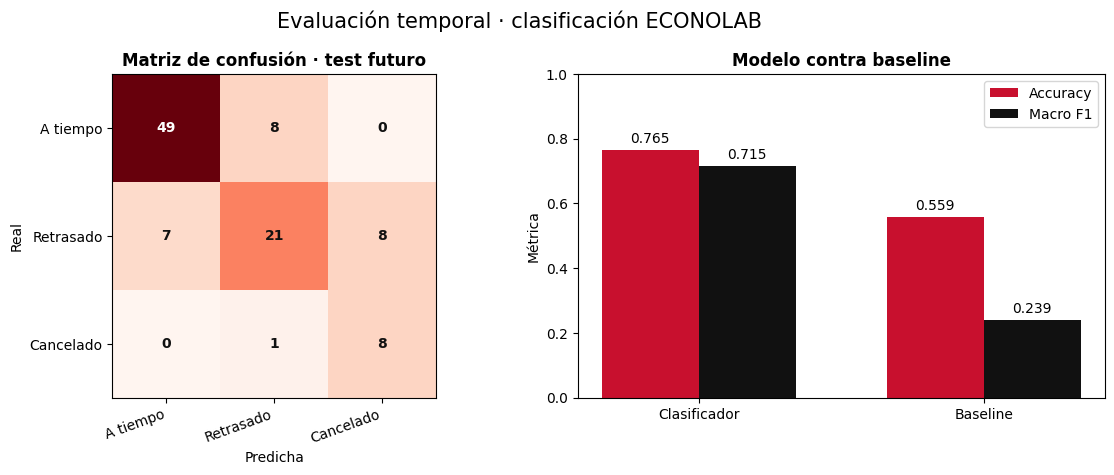

Evidencia: 09_Evidencias/clasificacion_matriz_confusion.png


In [7]:
matrix = pd.DataFrame(evaluation['confusionMatrix']).T.reindex(index=classes, columns=classes)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].imshow(matrix.values, cmap='Reds', vmin=0, vmax=matrix.values.max())
for i in range(len(classes)):
    for j in range(len(classes)):
        axes[0].text(j, i, int(matrix.iloc[i, j]), ha='center', va='center',
                     color=WHITE if matrix.iloc[i, j] > matrix.values.max()/2 else BLACK,
                     fontweight='bold')
axes[0].set_xticks(range(3), [labels[c] for c in classes], rotation=20, ha='right')
axes[0].set_yticks(range(3), [labels[c] for c in classes])
axes[0].set_xlabel('Predicha'); axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de confusión · test futuro')

x = range(2); width = .34
axes[1].bar([i-width/2 for i in x], comparison.accuracy, width, label='Accuracy', color=RED)
axes[1].bar([i+width/2 for i in x], comparison.macro_f1, width, label='Macro F1', color=BLACK)
axes[1].set_xticks(list(x), ['Clasificador', 'Baseline'])
axes[1].set_ylim(0, 1); axes[1].set_ylabel('Métrica')
axes[1].set_title('Modelo contra baseline')
axes[1].legend()
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.3f', padding=3)
fig.suptitle('Evaluación temporal · clasificación ECONOLAB', fontsize=15)
plt.tight_layout()
matrix_path = EVIDENCE / 'clasificacion_matriz_confusion.png'
plt.savefig(matrix_path, dpi=180, bbox_inches='tight', facecolor=WHITE)
plt.show()
print('Evidencia:', matrix_path.relative_to(PROJECT).as_posix())

### Interpretación de errores

El modelo mejora al baseline en accuracy y macro F1. La prioridad operativa es
revisar los servicios `delayed` pronosticados como `completed_on_time`, porque
son retrasos que no activarían una alerta. La clase cancelada tiene menos casos;
su recall debe leerse junto con precision y soporte, no de forma aislada.

## Fase 6 CRISP-DM — Despliegue e inferencia

La función siguiente replica el backend: aplica el preprocesamiento y los pesos
del JSON exacto sin consultar Y y sin volver a entrenar.

In [8]:
camel_to_csv = {
 'promisedLeadHours':'promised_lead_hours', 'registrationHour':'registration_hour',
 'registrationWeekday':'registration_weekday', 'itemCount':'item_count',
 'totalQuantity':'total_quantity', 'distinctStudyCount':'distinct_study_count',
 'packageComponentCount':'package_component_count', 'subtotalAmount':'subtotal_amount',
 'courtesyPercent':'courtesy_percent', 'discountAmount':'discount_amount',
 'totalAmount':'total_amount', 'branchName':'branch_name',
 'dominantPriceType':'dominant_price_type'
}
def normalize_category(value):
    if pd.isna(value): return '__missing__'
    text = ''.join(c for c in unicodedata.normalize('NFD', str(value))
                   if unicodedata.category(c) != 'Mn')
    return ' '.join(text.strip().lower().split()) or '__missing__'

def predict_artifact(row):
    vector = [1.0]
    for feature in artifact['preprocessing']['numeric']:
        value = row.get(camel_to_csv[feature['key']], feature['mean'])
        value = feature['mean'] if pd.isna(value) else float(value)
        vector.append((value-feature['mean'])/feature['standardDeviation'])
    for feature in artifact['preprocessing']['categorical']:
        value = normalize_category(row.get(camel_to_csv[feature['key']]))
        value = value if value in feature['categories'] else '__other__'
        vector.extend(1.0 if value == category else 0.0
                      for category in feature['categories'])
    scores = [sum(x*w for x,w in zip(vector, weights))
              for weights in artifact['classifier']['weights']]
    maximum = max(scores); exp = [math.exp(score-maximum) for score in scores]
    probabilities = [value/sum(exp) for value in exp]
    return classes[probabilities.index(max(probabilities))], probabilities

cases = test_df.groupby('outcome', group_keys=False).head(1).copy()
predictions = cases.apply(predict_artifact, axis=1)
cases['predicted'] = [value[0] for value in predictions]
for index, name in enumerate(classes):
    cases[f'p_{name}'] = [value[1][index] for value in predictions]
display(cases[['source_folio', 'source_created_at', 'is_synthetic', 'outcome',
               'predicted', *[f'p_{name}' for name in classes]]])

,source_folio,source_created_at,is_synthetic,outcome,predicted,p_completed_on_time,p_delayed,p_cancelled
0,ECO-ML-000041,2026-05-12 14:31:00+00:00,1,completed_on_time,delayed,0.178020,0.586366,0.235614
1,ECO-ML-000281,2026-05-12 14:31:00+00:00,1,cancelled,cancelled,0.021570,0.399058,0.579372
5,ECO-ML-000315,2026-05-14 16:45:00+00:00,1,delayed,delayed,0.159458,0.451881,0.388661


## Conclusión

El artefacto evaluado y desplegado aprende únicamente del periodo pasado,
supera el baseline y conserva evidencia por clase. El 97.66 % sintético permite
demostrar el pipeline, pero no acredita desempeño productivo: debe revalidarse
con más historial real, por sucursal y por periodo, antes de automatizar alertas.